# Exploratory Data Analysis: Horse Breeds Dataset

This notebook explores the horse breeds dataset collected during **EQUI-59**. We will analyze:
1. **Class Counts**: The distribution of images across the 7 breeds.
2. **Sample Visualization**: Displaying samples to verify quality and labels.
3. **Image Dimensions**: Checking for aspect ratio/resolution consistency.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Set up paths
DATA_DIR = Path("../data/raw/horse-breeds")
LABELS_FILE = DATA_DIR / "labels.json"

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Load Data

We load the `labels.json` file which maps the breed IDs (e.g., '01') to breed names (e.g., 'Appaloosa'). Then we iterate through all image files to build a DataFrame.

In [2]:
if not LABELS_FILE.exists():
    print(f"Error: Labels file not found at {LABELS_FILE}")
else:
    with open(LABELS_FILE, 'r') as f:
        label_map = json.load(f)
    print(f"Loaded {len(label_map)} breed labels: {list(label_map.values())}")

Loaded 11 breed labels: ['Akhal-Teke', 'Appaloosa', 'Orlov Trotter', 'Vladimir Heavy Draft', 'Percheron', 'Arabian', 'Friesian', 'Barb', 'Andalusian', 'Hanoverian', 'Lusitano']


In [3]:
def load_dataset_metadata(data_dir, label_map):
    data = []
    for img_path in tqdm(list(data_dir.glob("*.png")), desc="Scanning Images"):
        # Filename format: XX_YYY.png where XX is breed_id
        filename = img_path.name
        breed_id = filename.split('_')[0]
        
        if breed_id in label_map:
            breed_name = label_map[breed_id]
            
            # Get image dimensions (optional, can be slow for massive datasets)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    
                data.append({
                    'filename': filename,
                    'path': str(img_path),
                    'breed_id': breed_id,
                    'breed_name': breed_name,
                    'width': width,
                    'height': height,
                    'aspect_ratio': width / height
                })
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                
    return pd.DataFrame(data)

df = load_dataset_metadata(DATA_DIR, label_map)
print(f"Frames loaded: {len(df)}")
df.head()

Scanning Images: 100%|██████████| 703/703 [00:10<00:00, 65.88it/s]


Frames loaded: 703


,filename,path,breed_id,breed_name,width,height,aspect_ratio
0,01_001.png,..\data\raw\horse-breeds\01_001.png,01,Akhal-Teke,256,256,1.0
1,01_002.png,..\data\raw\horse-breeds\01_002.png,01,Akhal-Teke,256,256,1.0
2,01_003.png,..\data\raw\horse-breeds\01_003.png,01,Akhal-Teke,256,256,1.0
3,01_004.png,..\data\raw\horse-breeds\01_004.png,01,Akhal-Teke,256,256,1.0
4,01_005.png,..\data\raw\horse-breeds\01_005.png,01,Akhal-Teke,256,256,1.0


## 2. Class Distribution Analysis

C:\Users\oclaz\AppData\Local\Temp\ipykernel_12052\441117507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.index, y=breed_counts.values, palette='viridis')


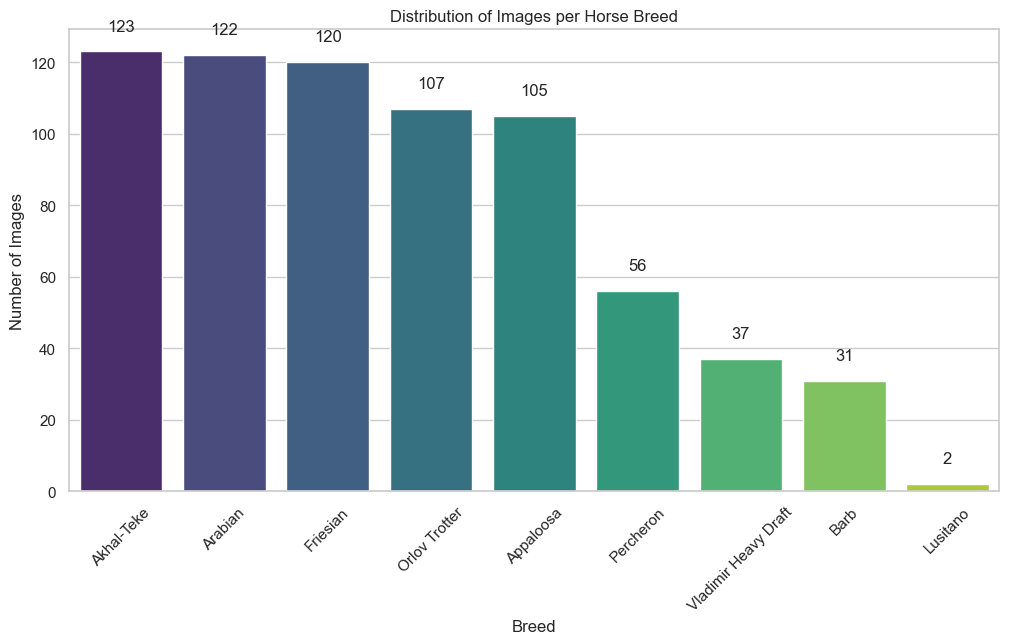

In [4]:
breed_counts = df['breed_name'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=breed_counts.index, y=breed_counts.values, palette='viridis')
plt.title('Distribution of Images per Horse Breed')
plt.xlabel('Breed')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
for i, v in enumerate(breed_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

## 3. Image Property Analysis

Checking resolution and aspect ratios is crucial for ML preprocessing. If images are very small or extremely wide/tall, standard resizing might distort features.

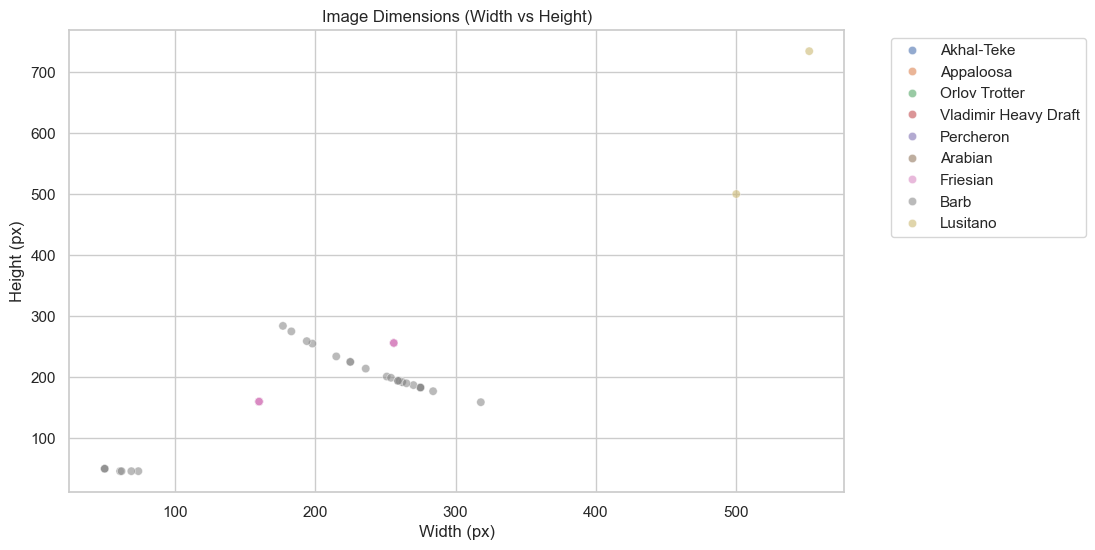

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='width', y='height', hue='breed_name', alpha=0.6)
plt.title('Image Dimensions (Width vs Height)')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 4. Sample Visualization

Displaying random samples from each class to verify the data quality visually.

ValueError: Cannot take a larger sample than population when 'replace=False'

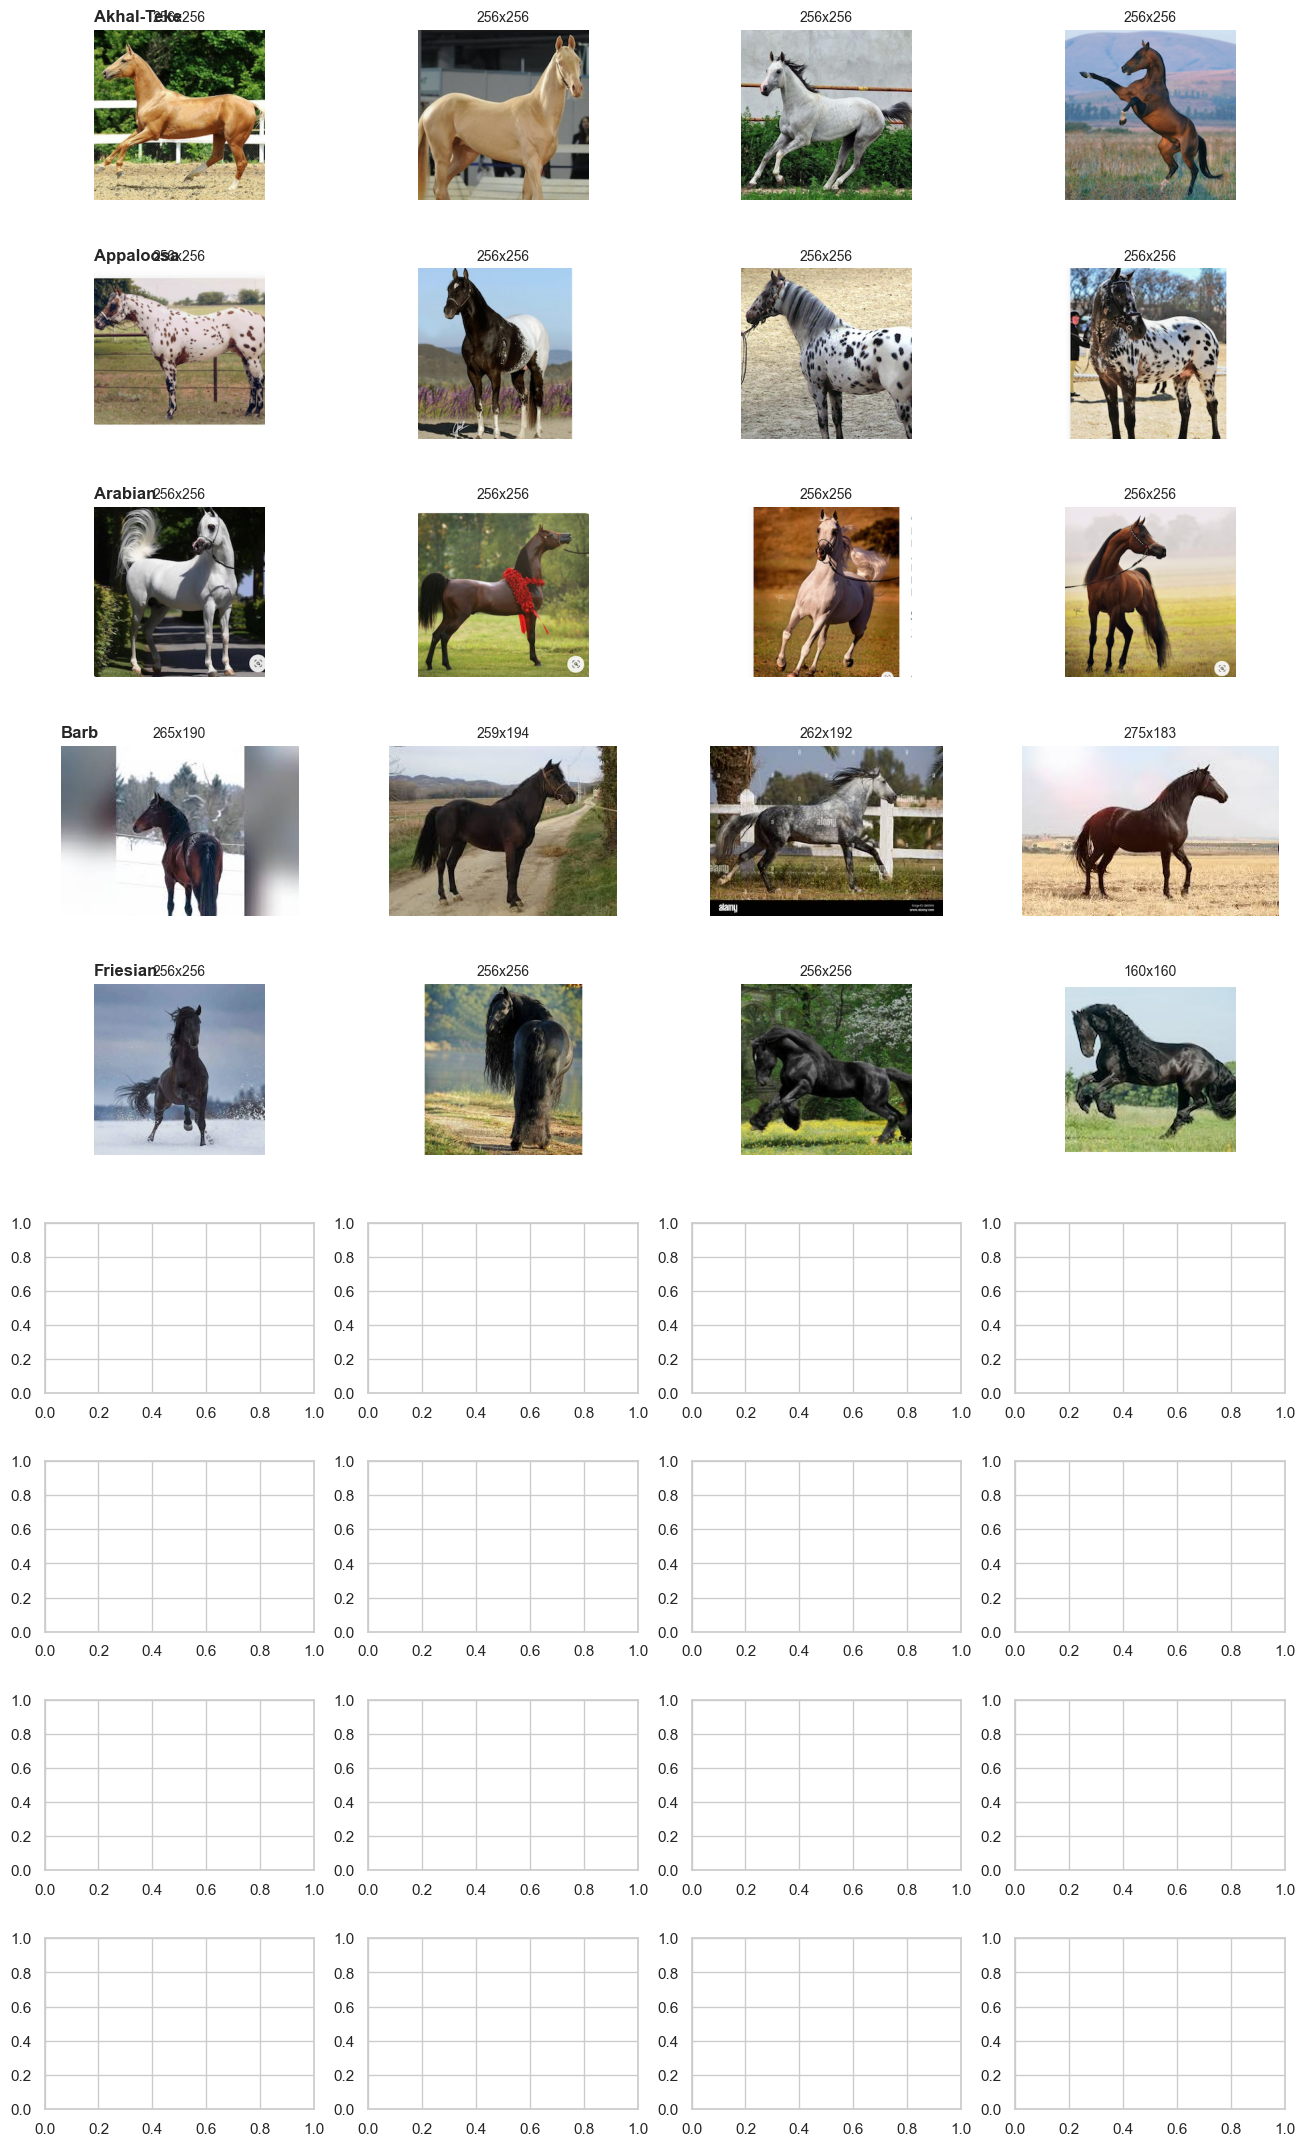

In [6]:
def show_samples(df, n_samples=3):
    breeds = df['breed_name'].unique()
    n_breeds = len(breeds)
    
    fig, axes = plt.subplots(n_breeds, n_samples, figsize=(n_samples*4, n_breeds*3))
    plt.subplots_adjust(hspace=0.4)
    
    for i, breed in enumerate(sorted(breeds)):
        samples = df[df['breed_name'] == breed].sample(n_samples)
        for j, (_, row) in enumerate(samples.iterrows()):
            ax = axes[i, j] if n_breeds > 1 else axes[j]
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(breed, fontsize=12, loc='left', fontweight='bold')
            ax.set_title(f"{row['width']}x{row['height']}", fontsize=10)
            
    plt.show()

show_samples(df, n_samples=4)